# Projeto Integrador — G3: Latência / proxy de QoE

**Disciplina:** Análise de Dados em Redes de Telecom (Módulo 09) · **Grupo 5 (interno) / Tema oficial G3**
**Equipe:** Carlos Alberto · Éverton Gomes · Gerson Francisco · Luiz Carlos Santos

**Pergunta do grupo:** quando o atraso de rádio (`DRB.RlcSduDelayDl`) sugere que a experiência do usuário
pode estar ruim? Usamos o atraso como **proxy de QoE** — o laboratório **não** produz uma nota MOS de
aplicativo real, então toda conclusão aqui é sobre o *proxy*, não sobre QoE medida de fato.

**Fonte dos dados (trilha offline oficial):**
`data/code/datasets/kpm-ue-tp-sample/kpm.jsonl` — artefatos KPM disponibilizados pelo docente,
gerados no lab `oai-cn-gnb-nonrt-nearrt` (RFSIM, telemetria sintética, sem dados pessoais).

**Pipeline deste notebook:**
`ler os dados → limpar/organizar → indicador 1 (atraso) → indicador 2 (fração acima do limiar) →
cruzar com vazão → visualizar → recomendação (A1 simulada) → limitações`


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)


## 1. Carregar `kpm.jsonl`

O caminho abaixo é relativo à posição deste notebook
(`data/projeto-g3-latencia/notebook_g3_latencia.ipynb`), apontando para o dataset oficial em
`data/code/datasets/kpm-ue-tp-sample/kpm.jsonl`. Ajuste `DATA_PATH` se você mover o notebook.


In [2]:
DATA_PATH = Path("../code/datasets/kpm-ue-tp-sample/kpm.jsonl")
assert DATA_PATH.exists(), f"Não encontrei {DATA_PATH.resolve()} — confira o caminho do dataset."

records = [json.loads(line) for line in DATA_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
raw = pd.json_normalize(records)
print(f"{len(raw)} amostras carregadas de {DATA_PATH}")
raw.head()


100 amostras carregadas de ..\code\datasets\kpm-ue-tp-sample\kpm.jsonl


,ingested_at,phase,run_id,sample_index,source_path,metrics.DRB.RlcSduDelayDl,metrics.DRB.UEThpUl,metrics.RRU.PrbTotUl
0,2026-08-04T20:44:22.310716+00:00,baseline,ue-tp-20260804-174422,0,/home/jakunzler/Documents/GitHub/cesar/cesar-s...,55.0,4.46,2.0
1,2026-08-04T20:44:22.310716+00:00,baseline,ue-tp-20260804-174422,1,/home/jakunzler/Documents/GitHub/cesar/cesar-s...,218.0,3.72,2.0
2,2026-08-04T20:44:22.310716+00:00,baseline,ue-tp-20260804-174422,2,/home/jakunzler/Documents/GitHub/cesar/cesar-s...,137.0,3.72,2.0
3,2026-08-04T20:44:22.310716+00:00,baseline,ue-tp-20260804-174422,3,/home/jakunzler/Documents/GitHub/cesar/cesar-s...,171.0,3.72,2.0
4,2026-08-04T20:44:22.310716+00:00,baseline,ue-tp-20260804-174422,4,/home/jakunzler/Documents/GitHub/cesar/cesar-s...,39.0,3.72,2.0


## 2. Organizar colunas

Cada linha do JSONL tem um dicionário `metrics` com as três features do lab
(`DRB.RlcSduDelayDl`, `DRB.UEThpUl`, `RRU.PrbTotUl`). O `json_normalize` já achata isso em colunas
`metrics.<nome>` — vamos renomear para algo mais curto e definir os tipos.


In [3]:
df = raw.rename(columns={
    "metrics.DRB.RlcSduDelayDl": "delay_dl_us",
    "metrics.DRB.UEThpUl": "thp_ul_kbps",
    "metrics.RRU.PrbTotUl": "prb_ul_pct",
})[["run_id", "phase", "sample_index", "delay_dl_us", "thp_ul_kbps", "prb_ul_pct", "ingested_at"]]

df["phase"] = pd.Categorical(df["phase"], categories=["baseline", "stress", "recovery"], ordered=True)
df = df.sort_values(["phase", "sample_index"]).reset_index(drop=True)

df.dtypes


run_id               str
phase           category
sample_index       int64
delay_dl_us      float64
thp_ul_kbps      float64
prb_ul_pct       float64
ingested_at          str
dtype: object

## 2.1 Arquitetura de dados (checkpoint da Aula 02)

A Aula 02 (Lakes/warehouses/DBs) pede, além dos indicadores, uma justificativa de **onde os dados
são persistidos** e por quê — no formato bronze/silver/gold usado no material da disciplina:

| Camada | Artefato do lab | Papel |
|---|---|---|
| Bronze (bruto) | `kpm.jsonl` | Um registro por linha, como veio do experimento; schema-on-read |
| Silver (tipado) | `kpm.sqlite` (tabelas `runs` + `kpm_samples`) | Consultável via SQL, mesma informação já estruturada |
| Gold (curado) | `model.json`, `decision.json`, indicadores deste notebook | KPIs e recomendação prontos para decisão |

Abaixo replicamos, via `sqlite3` do Python (equivalente ao `sqlite3` de terminal mostrado na
Demo 1a da Aula 02), a mesma consulta feita direto em `kpm.jsonl` — para confirmar que bronze e
silver contam a mesma história.


In [4]:
import sqlite3

SQLITE_PATH = Path("../code/datasets/kpm-ue-tp-sample/kpm.sqlite")
assert SQLITE_PATH.exists(), f"Não encontrei {SQLITE_PATH.resolve()}"

con = sqlite3.connect(SQLITE_PATH)
cur = con.cursor()

print("Tabelas:")
print(cur.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall())

print("\nContagem por fase (kpm_samples, silver):")
print(cur.execute("SELECT phase, COUNT(*) FROM kpm_samples GROUP BY phase").fetchall())

print("\nPrimeiras 5 amostras de DRB.UEThpUl em 'stress' (via json_extract no payload_json):")
rows = cur.execute(
    "SELECT phase, sample_index, json_extract(payload_json,'$.\"DRB.UEThpUl\"') AS ue_thp_ul "
    "FROM kpm_samples WHERE phase='stress' ORDER BY sample_index LIMIT 5"
).fetchall()
for row in rows:
    print(row)

con.close()


Tabelas:
[('runs',), ('kpm_samples',), ('sqlite_sequence',)]

Contagem por fase (kpm_samples, silver):
[('baseline', 20), ('recovery', 20), ('stress', 60)]

Primeiras 5 amostras de DRB.UEThpUl em 'stress' (via json_extract no payload_json):
('stress', 0, 15.16)
('stress', 1, 79787.77)
('stress', 2, 74298.14)
('stress', 3, 82823.86)
('stress', 4, 80928.66)


**Cuidado — pegadinha real do dataset:** o comando de exemplo da Aula 02 (slide "Demo 1a") usa
`json_extract(payload_json,'$.DRB.UEThpUl')`. Nesse dataset **isso retorna `NULL` silenciosamente**,
porque a chave `DRB.UEThpUl` dentro do `payload_json` é um nome literal com ponto
(`{"DRB.UEThpUl": ...}`), e o SQLite interpreta `.` no path do `json_extract` como separador de
nível (procuraria por `{"DRB": {"UEThpUl": ...}}`, que não existe). A correção é citar a chave entre
aspas no path — `'$."DRB.UEThpUl"'` — como fizemos acima. Vale mencionar isso na apresentação: é um
erro fácil de cometer copiando o exemplo do slide direto no terminal.

**Por que SQLite/JSONL e não InfluxDB ou Redis RNIB?**

- **InfluxDB** é o TSDB do caminho Non-RT/OSC (VES → Kafka → Influx Logger), pensado para
  telemetria **contínua e em stream** vinda de um RIC ao vivo. Aqui a trilha é **offline**: temos
  um conjunto fixo de 100 amostras já coletadas pelo docente, sem stack near-RT rodando — não há
  fluxo contínuo para justificar um TSDB.
- **Redis `ric_dbaas`** guarda o RNIB (inventário de nós E2 conectados ao Near-RT RIC) — é estado
  operacional de uma RIC ativa, não histórico de métricas. Como não estamos com o lab E2 no ar,
  não há inventário a consultar.
- **SQLite** cobre exatamente o que o grupo precisa: uma camada "silver" tipada, consultável por
  SQL, local, sem servidor — ideal para a trilha offline obrigatória. O `kpm.jsonl` (bronze) fica
  como espelho bruto, útil para reprocessar com pandas caso mudemos a fórmula de algum indicador.


## 3. Checagem de qualidade (parte do Checkpoint 1)

Antes de calcular qualquer indicador, confirmamos: contagem por fase, valores nulos e duplicados,
e uma visão estatística rápida (`describe`). Isso é o que a rubrica chama de "aquisição, preparação
e qualidade dos dados" (2,0 pts).


In [5]:
print("Amostras por fase:")
print(df["phase"].value_counts().sort_index())

print("\nValores nulos por coluna:")
print(df[["delay_dl_us", "thp_ul_kbps", "prb_ul_pct"]].isna().sum())

dup = df.duplicated(subset=["run_id", "phase", "sample_index"]).sum()
print(f"\nLinhas duplicadas (run_id+phase+sample_index): {dup}")

df[["delay_dl_us", "thp_ul_kbps", "prb_ul_pct"]].describe()


Amostras por fase:
phase
baseline    20
stress      60
recovery    20
Name: count, dtype: int64

Valores nulos por coluna:
delay_dl_us    0
thp_ul_kbps    0
prb_ul_pct     0
dtype: int64

Linhas duplicadas (run_id+phase+sample_index): 0


,delay_dl_us,thp_ul_kbps,prb_ul_pct
count,100.000000,100.000000,100.000000
mean,124.005400,48754.863500,59.390000
std,83.733182,41088.919011,47.731762
min,0.000000,3.000000,2.000000
25%,52.500000,3.720000,2.000000
50%,154.530000,78511.820000,99.000000
75%,161.712500,80312.967500,99.000000
max,470.000000,172316.900000,99.000000


### 3.1 Achado importante — amostras "ociosas" (sem tráfego DL)

Antes de calcular indicadores, vale checar **quantas amostras têm `delay_dl_us == 0`**. Isso não é
erro de dado: quando não há tráfego no downlink, não existe SDU RLC para medir atraso, e a métrica
fica zerada. Isso é diferente de "atraso baixo/bom".


In [6]:
idle = df["delay_dl_us"] == 0
resumo_idle = (
    df.groupby("phase", observed=True)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "amostras_ociosas_delay0": int((g["delay_dl_us"] == 0).sum()),
        "pct_ociosas": round(100 * (g["delay_dl_us"] == 0).mean(), 1),
    }), include_groups=False)
)
resumo_idle


,n,amostras_ociosas_delay0,pct_ociosas
phase,,,
baseline,20.0,11.0,55.0
stress,60.0,0.0,0.0
recovery,20.0,11.0,55.0


**Leitura:** em `baseline` e `recovery`, ~55% das amostras são ociosas (delay=0, vazão residual de
poucos kbps) — o UE está conectado mas sem tráfego DL ativo. Em `stress`, 100% das amostras têm
tráfego real. Por isso, a mediana "bruta" do atraso em `baseline`/`recovery` sai **0** — não porque
o desempenho seja ótimo, mas porque metade do tempo não há nada para medir. Calculamos os
indicadores das duas formas: **bruto** (todas as amostras, como pedido no card do grupo) e
**apenas com tráfego ativo** (excluindo `delay == 0`), para dar contexto correto na apresentação.


## 4. Indicador 1 — Atraso RLC por fase (mediana e p95)

**Definição:** para cada fase do experimento (`baseline`, `stress`, `recovery`), calculamos a
**mediana** e o **percentil 95** de `DRB.RlcSduDelayDl` (µs). A mediana mostra o comportamento
típico; o p95 mostra o pior caso "não-outlier", que é o que mais afeta a experiência do usuário.

Mostramos a versão **bruta** (todas as amostras — é o indicador oficial do card do grupo) e, logo
abaixo, uma versão **só com tráfego ativo** (`delay_dl_us > 0`) só para explicar por que o valor
bruto de `baseline`/`recovery` fica em zero.


In [7]:
indicador_1 = (
    df.groupby("phase", observed=True)["delay_dl_us"]
    .agg(mediana_us="median", p95_us=lambda s: np.percentile(s, 95), n="count")
    .round(1)
)
indicador_1


,mediana_us,p95_us,n
phase,,,
baseline,0.0,185.7,20
stress,158.9,191.2,60
recovery,0.0,394.0,20


In [8]:
indicador_1_trafego_ativo = (
    df.loc[df["delay_dl_us"] > 0]
    .groupby("phase", observed=True)["delay_dl_us"]
    .agg(mediana_us="median", p95_us=lambda s: np.percentile(s, 95), n="count")
    .round(1)
)
indicador_1_trafego_ativo


,mediana_us,p95_us,n
phase,,,
baseline,137.0,204.4,9
stress,158.9,191.2,60
recovery,126.0,438.0,9


## 5. Indicador 2 — Fração do tempo com atraso acima do limiar

**Escolha do limiar:** usamos o **percentil 75 do atraso na fase `baseline`** como referência de
"comportamento normal aceitável". Qualquer amostra (em qualquer fase) acima desse valor é contada
como "degradada". O limiar é calculado a partir dos dados — não é um número arbitrário — e fica
registrado abaixo para o README do grupo.


In [9]:
limiar_us = np.percentile(df.loc[df["phase"] == "baseline", "delay_dl_us"], 75)
print(f"Limiar de atraso (p75 do baseline): {limiar_us:.1f} us")

df["acima_limiar"] = df["delay_dl_us"] > limiar_us

indicador_2 = (
    df.groupby("phase", observed=True)["acima_limiar"]
    .mean()
    .mul(100)
    .round(1)
    .rename("pct_amostras_acima_limiar")
)
indicador_2


Limiar de atraso (p75 do baseline): 105.5 us


phase
baseline     25.0
stress      100.0
recovery     25.0
Name: pct_amostras_acima_limiar, dtype: float64

### 5.1 Checagem de robustez do limiar (fechamento — Aula 04 / Checkpoint 2)

Antes de fechar o indicador, testamos uma alternativa: calcular o p75 **só com as amostras de
tráfego ativo do baseline** (excluindo os `delay == 0` da seção 3.1), já que "atraso típico durante
uso" é conceitualmente mais limpo que "atraso típico incluindo períodos ociosos".


In [10]:
baseline_ativo = df.loc[(df["phase"] == "baseline") & (df["delay_dl_us"] > 0), "delay_dl_us"]
limiar_alternativo = np.percentile(baseline_ativo, 75)

print(f"Amostras de baseline com tráfego ativo: {len(baseline_ativo)}")
print(f"Limiar alternativo (p75 do baseline só ativo): {limiar_alternativo:.1f} us")
print(f"Limiar oficial (p75 do baseline bruto, n=20):  {limiar_us:.1f} us")


Amostras de baseline com tráfego ativo: 9
Limiar alternativo (p75 do baseline só ativo): 171.0 us
Limiar oficial (p75 do baseline bruto, n=20):  105.5 us


**Decisão final do grupo:** mantivemos o limiar oficial em **105.5 µs (p75 do baseline bruto,
n=20)**, e não trocamos pela alternativa "só ativo" (171.0 µs). Motivo: a alternativa usa apenas
**9 amostras** — um percentil calculado sobre uma amostra tão pequena é instável (uma única amostra
a mais ou a menos desloca o valor de forma significativa). O limiar bruto usa as 20 amostras do
baseline e é mais estável, mesmo misturando períodos ociosos e ativos.

Isso fica registrado aqui como **checagem de robustez**, não como indecisão: consideramos a
alternativa, teste os números, e documentamos por que a rejeitamos. É esse tipo de registro que a
rubrica de "governança" do briefing pede.

### 5.2 Definição formal dos 2 indicadores (exigência do briefing)

| Indicador | Fórmula | Granularidade | Fonte |
|---|---|---|---|
| **KPI 1 — Atraso RLC típico** | Mediana e percentil 95 de `DRB.RlcSduDelayDl` (µs) | Por fase do experimento (`baseline` / `stress` / `recovery`), todas as amostras | `kpm.jsonl` / `kpm.sqlite`, campo `DRB.RlcSduDelayDl` |
| **KPI 2 — Fração de tempo degradado** | % de amostras com `DRB.RlcSduDelayDl` > 105,5 µs (p75 do baseline bruto) | Por fase, todas as amostras | Mesmo campo; limiar calculado sobre a fase `baseline` |


## 6. Cruzamento com vazão (`DRB.UEThpUl`)

A hipótese do proxy de QoE fica mais forte quando **atraso alto coincide com vazão baixa** — isso
sugere degradação real da experiência, não apenas ruído de medição. Calculamos a correlação de
Pearson entre atraso e vazão, por fase, e olhamos a média de vazão dentro/fora das amostras
"acima do limiar".

**Atenção ao ler o resultado:** por causa das amostras ociosas (seção 3.1), a correlação "bruta"
mistura dois regimes bem diferentes — UE parado (delay≈0, thp≈3-5 kbps) e UE ativo (delay>0,
thp na casa de dezenas de milhares de kbps). Isso pode inflar a correlação de forma enganosa.
Por isso repetimos o cálculo **só com tráfego ativo**, que é a comparação relevante para a
hipótese de QoE do grupo.


In [11]:
correlacao_por_fase = df.groupby("phase", observed=True)[["delay_dl_us", "thp_ul_kbps"]].corr().unstack().iloc[:, 1]
correlacao_por_fase.name = "correlacao_delay_thp_bruta"
print(correlacao_por_fase.round(3))

print("\nVazão média (kbps) dentro vs fora do limiar de atraso (todas as amostras):")
print(df.groupby("acima_limiar", observed=True)["thp_ul_kbps"].mean().round(2))


phase
baseline    0.113
stress      0.162
recovery   -0.079
Name: correlacao_delay_thp_bruta, dtype: float64

Vazão média (kbps) dentro vs fora do limiar de atraso (todas as amostras):
acima_limiar
False     5747.47
True     67186.60
Name: thp_ul_kbps, dtype: float64


In [12]:
df_ativo = df.loc[df["delay_dl_us"] > 0]
correlacao_trafego_ativo = (
    df_ativo.groupby("phase", observed=True)[["delay_dl_us", "thp_ul_kbps"]]
    .corr().unstack().iloc[:, 1]
)
correlacao_trafego_ativo.name = "correlacao_delay_thp_trafego_ativo"
print(correlacao_trafego_ativo.round(3))


phase
baseline   -0.377
stress      0.162
recovery   -0.345
Name: correlacao_delay_thp_trafego_ativo, dtype: float64


## 7. Visualizações

### 7.1 Série temporal do atraso por fase


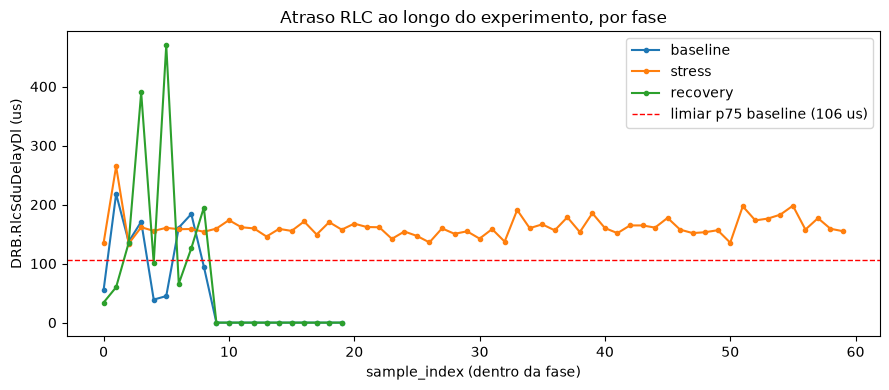

In [13]:
fig, ax = plt.subplots()
for phase, grp in df.groupby("phase", observed=True):
    ax.plot(grp["sample_index"], grp["delay_dl_us"], marker="o", markersize=3, label=phase)
ax.axhline(limiar_us, color="red", linestyle="--", linewidth=1, label=f"limiar p75 baseline ({limiar_us:.0f} us)")
ax.set_xlabel("sample_index (dentro da fase)")
ax.set_ylabel("DRB.RlcSduDelayDl (us)")
ax.set_title("Atraso RLC ao longo do experimento, por fase")
ax.legend()
fig.tight_layout()
plt.show()


### 7.2 Distribuição do atraso por fase (boxplot)

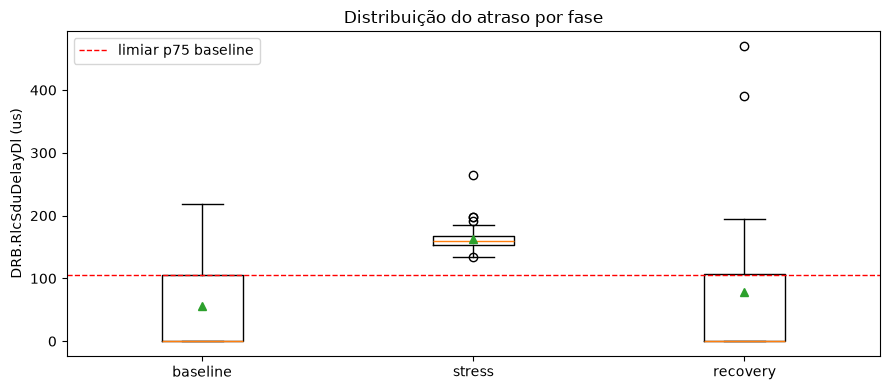

In [14]:
fig, ax = plt.subplots()
data_por_fase = [df.loc[df["phase"] == p, "delay_dl_us"].dropna() for p in ["baseline", "stress", "recovery"]]
ax.boxplot(data_por_fase, tick_labels=["baseline", "stress", "recovery"], showmeans=True)
ax.axhline(limiar_us, color="red", linestyle="--", linewidth=1, label="limiar p75 baseline")
ax.set_ylabel("DRB.RlcSduDelayDl (us)")
ax.set_title("Distribuição do atraso por fase")
ax.legend()
fig.tight_layout()
plt.show()


### 7.3 Atraso vs. vazão (dispersão)

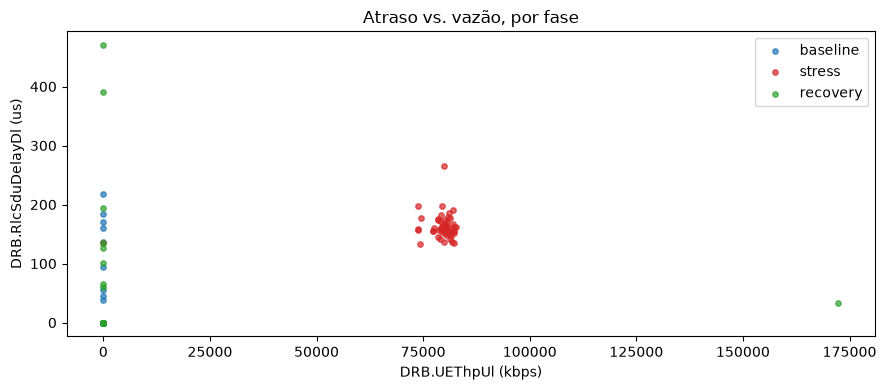

In [15]:
fig, ax = plt.subplots()
colors = {"baseline": "tab:blue", "stress": "tab:red", "recovery": "tab:green"}
for phase, grp in df.groupby("phase", observed=True):
    ax.scatter(grp["thp_ul_kbps"], grp["delay_dl_us"], s=15, alpha=0.7, label=phase, color=colors[phase])
ax.set_xlabel("DRB.UEThpUl (kbps)")
ax.set_ylabel("DRB.RlcSduDelayDl (us)")
ax.set_title("Atraso vs. vazão, por fase")
ax.legend()
fig.tight_layout()
plt.show()


## 8. Recomendação operacional / política A1 (execução simulada)

Seguindo o formato dos artefatos do lab (`decision.json`), montamos uma recomendação **simulada
(dry-run)**: se a fração de amostras acima do limiar em `stress` ultrapassar um gatilho (ex.: 50%),
propomos investigar a sessão / priorizar tráfego via política A1 candidata. Isso **não** aciona
nada real — é só o formato de decisão que o pipeline do lab usa.


In [16]:
GATILHO_PCT = 50.0
fase_critica = indicador_2[indicador_2 > GATILHO_PCT]

recomendacao = {
    "grupo": "G3 - Latencia / proxy de QoE",
    "limiar_atraso_us": round(float(limiar_us), 1),
    "indicador_1_delay_por_fase": indicador_1.to_dict(orient="index") if hasattr(indicador_1, "to_dict") else indicador_1.to_dict(),
    "indicador_2_pct_acima_limiar": indicador_2.round(1).to_dict(),
    "fases_criticas": fase_critica.index.tolist(),
    "decisao": "apply" if len(fase_critica) > 0 else "observe",
    "politica_A1_simulada": {
        "policy_id": "g3-latencia-priorizacao-dry-run",
        "acao": "priorizar trafego / investigar sessao" if len(fase_critica) > 0 else "manter observacao",
        "execucao": "simulada (dry-run) - sem atuacao real na RAN",
    },
    "aviso": "Atraso RLC e um PROXY de QoE. Nao ha nota MOS de aplicativo real neste lab.",
}

print(json.dumps(recomendacao, indent=2, ensure_ascii=False))


{
  "grupo": "G3 - Latencia / proxy de QoE",
  "limiar_atraso_us": 105.5,
  "indicador_1_delay_por_fase": {
    "baseline": {
      "mediana_us": 0.0,
      "p95_us": 185.7,
      "n": 20
    },
    "stress": {
      "mediana_us": 158.9,
      "p95_us": 191.2,
      "n": 60
    },
    "recovery": {
      "mediana_us": 0.0,
      "p95_us": 394.0,
      "n": 20
    }
  },
  "indicador_2_pct_acima_limiar": {
    "baseline": 25.0,
    "stress": 100.0,
    "recovery": 25.0
  },
  "fases_criticas": [
    "stress"
  ],
  "decisao": "apply",
  "politica_A1_simulada": {
    "policy_id": "g3-latencia-priorizacao-dry-run",
    "acao": "priorizar trafego / investigar sessao",
    "execucao": "simulada (dry-run) - sem atuacao real na RAN"
  },
  "aviso": "Atraso RLC e um PROXY de QoE. Nao ha nota MOS de aplicativo real neste lab."
}


**Em português simples (checkpoint técnico final — Aula 05):** na fase de `stress`, 100% das
amostras ficaram acima do limiar de atraso — não é um pico isolado, é degradação sustentada durante
toda a janela de carga. Em `baseline` e `recovery`, só 25% das amostras ficaram acima, dentro do que
esperamos de variação normal. Por isso a política A1 candidata (priorizar tráfego / investigar a
sessão) só seria proposta durante `stress`; nas outras fases a decisão do pipeline é "observar", sem
acionar nada.

**Isso não é uma ação real.** É uma recomendação simulada (*dry-run*) no mesmo formato que o pipeline
do laboratório usa (`decision.json`) — nenhuma política foi enviada a um RIC de verdade, nenhuma
configuração de rede foi alterada. O objetivo é mostrar que os dados sustentam uma decisão
operacional específica, não aplicá-la.


## 9. Limitações

- **RFSIM ≠ rede real:** o rádio é simulado (OAI RFSIM); resultados não generalizam diretamente
  para uma rede comercial.
- **Sem QoE medida de fato:** `DRB.RlcSduDelayDl` é um proxy técnico de latência de rádio, não uma
  nota de experiência de aplicativo (MOS) reportada por usuário real.
- **Poucos UEs no experimento:** a agregação por fase é didática, não estatística de campus real.
- **Limiar com trade-off documentado:** usamos o p75 do baseline bruto (105,5 µs, n=20) em vez da
  alternativa só-com-tráfego-ativo (171,0 µs, n=9) por robustez estatística — ver seção 5.1. Outro
  critério de limiar mudaria os percentuais do indicador 2; deixamos o cálculo explícito no notebook
  para que qualquer pessoa possa testar outro valor.
- **Amostras ociosas contam como "sem degradação":** como `delay_dl_us == 0` nunca ultrapassa o
  limiar, os 55% de amostras ociosas em `baseline`/`recovery` (seção 3.1) puxam o indicador 2 para
  baixo nessas fases — isso é uma limitação conhecida do indicador, não um erro de cálculo.
- **Dados sintéticos/simulados:** conforme `README.md` do dataset, sem dados pessoais, uso apenas
  acadêmico neste módulo.

## 10. Conclusão — registro de decisões do grupo (checkpoints Aula 02 → Aula 05)

Este notebook, na ordem em que está escrito, é o histórico reprodutível de todos os checkpoints do
projeto até aqui:

| Checkpoint | O que foi decidido | Onde está |
|---|---|---|
| Aula 02 — arquitetura | SQLite/JSONL (bronze/silver/gold); por que não InfluxDB/Redis | Seção 2.1 |
| Aula 03 — Checkpoint 1 (EDA) | Qualidade dos dados checada; achado das amostras ociosas | Seções 3 e 3.1 |
| Aula 04 — Checkpoint 2 (KPIs) | Indicadores formalizados; limiar testado e validado por robustez | Seções 4, 5, 5.1, 5.2 |
| Aula 05 — checkpoint técnico final | Recomendação operacional + política A1 simulada + limitações | Seções 8 e 9 |
| Aula 06 — apresentação | Material consolidado para os slides e a defesa individual | Este notebook completo |

Qualquer pessoa do grupo (ou de outro grupo) consegue reabrir este notebook, rodar
**Kernel → Restart & Run All**, e chegar exatamente nesses mesmos números e gráficos — é essa a ideia
de "pipeline reprodutível" pedida no briefing.
